In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [21]:
df = pd.read_excel('/Facebook Friends.xlsx')
df_csv = pd.read_csv('/Facebook Friends.csv')
df_txt = pd.read_csv('/Facebook Friends.txt', sep='\t', encoding='latin1')

when importing different types of files using pandas, we have to specify the file type ==> pd.read_filetype('path of the file')
Another thing to note here is that both csv and txt file can be imported by the pd.read_csv we just need to specify in the case if the values are separated by something other than commas (like tab, space)

In [4]:
df.head()

,Sample,Age,Photos,# of Tags,Albums,Gender,Emp,Profile,Cover,Orientation,Relationship,Posts,Replies,Children,Likes,Edu,Events,Friends
0,1,57,7,27,5,1,1,1,0,1,1,1,0,3,21,0,0,68
1,2,42,531,241,19,0,0,0,0,1,1,5,1,3,9,0,1,234
2,3,42,1396,423,40,0,1,1,0,1,1,186,31,2,43,1,1,727
3,4,55,394,139,48,0,1,1,1,1,1,6,4,2,187,0,4,437
4,5,30,916,231,78,1,1,1,1,1,1,412,752,1,34,0,2,372


In [5]:
df.tail()

,Sample,Age,Photos,# of Tags,Albums,Gender,Emp,Profile,Cover,Orientation,Relationship,Posts,Replies,Children,Likes,Edu,Events,Friends
710,711,25,499,4,0,0,1,1,1,1,1,16,19,0,49,0,11,1689
711,712,22,232,101,4,1,0,1,0,1,0,698,552,0,223,0,4,327
712,713,22,327,329,29,1,1,1,0,1,1,543,399,0,520,0,6,706
713,714,24,219,0,8,1,1,1,1,1,0,2,7,1,66,1,1,500
714,715,19,465,0,22,0,1,1,0,1,1,3,6,0,990,1,3,585


In [6]:
df.shape

(715, 18)

In [7]:
df.describe(include = 'all').T

,count,mean,std,min,25%,50%,75%,max
Sample,715.0,358.000000,206.547008,1.0,179.5,358.0,536.5,715.0
Age,715.0,24.406993,6.969578,13.0,21.0,22.0,25.0,81.0
Photos,715.0,723.914685,1265.112304,0.0,124.5,320.0,757.0,11995.0
# of Tags,715.0,458.096503,720.835481,0.0,75.5,250.0,566.5,10460.0
Albums,715.0,18.952448,22.502860,0.0,6.0,12.0,22.5,172.0
Gender,715.0,0.541259,0.517932,0.0,0.0,1.0,1.0,2.0
Emp,715.0,0.745455,0.435910,0.0,0.0,1.0,1.0,1.0
Profile,715.0,0.917483,0.275344,0.0,1.0,1.0,1.0,1.0
Cover,715.0,0.507692,0.500291,0.0,0.0,1.0,1.0,1.0
Orientation,715.0,0.956643,0.203801,0.0,1.0,1.0,1.0,1.0


The describe() function in pandas provides a summary of the central tendency, dispersion, and shape of a dataset's distribution, excluding Null values. When we use df.describe().T, it transposes the output, making the column names appear as rows, and the statistical measures as columns, which often makes it easier to read.
The Statistical measures that are calculated are as follows:

1.   **Count:** This indicates the number of non-null (non-missing) observations for each column. Since all counts are 715, it confirms that there are no missing values in any of these columns.
2. **Mean:** This is the average value of the column. For example, the average Age is approximately 24.41, and the average number of Friends is about 695.85.
3. **Std:** This stands for standard deviation, which measures the amount of variation or dispersion of a set of values. A low standard deviation indicates that the values tend to be close to the mean, while a high standard deviation indicates that the values are spread out over a wider range.
4. **Min:** This is the minimum value found in the column.
5. **25%:** This is the 25th percentile, meaning 25% of the data falls below this value. It's also known as the first quartile (Q1).
6. **50%:** This is the 50th percentile, which is the middle value of the dataset when ordered. It's also known as the median or the second quartile (Q2).
7. **75%:** This is the 75th percentile, meaning 75% of the data falls below this value. It's also known as the third quartile (Q3).
8. **max:** This is the maximum value found in the column.

These statistical attributes helps us to quickly understand the distribution, spread, and potential outliers within each numerical column of our dataset.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Sample        715 non-null    int64
 1   Age           715 non-null    int64
 2   Photos        715 non-null    int64
 3   # of Tags     715 non-null    int64
 4   Albums        715 non-null    int64
 5   Gender        715 non-null    int64
 6   Emp           715 non-null    int64
 7   Profile       715 non-null    int64
 8   Cover         715 non-null    int64
 9   Orientation   715 non-null    int64
 10  Relationship  715 non-null    int64
 11  Posts         715 non-null    int64
 12  Replies       715 non-null    int64
 13  Children      715 non-null    int64
 14  Likes         715 non-null    int64
 15  Edu           715 non-null    int64
 16  Events        715 non-null    int64
 17  Friends       715 non-null    int64
dtypes: int64(18)
memory usage: 100.7 KB


With df.info() we can see each column contains 715 entries and the "715 non-null" signifies that their are no missing values in our file.

In [9]:
df.columns

Index(['Sample ', 'Age', 'Photos', '# of Tags', 'Albums', 'Gender ', 'Emp',
       'Profile', 'Cover', 'Orientation', 'Relationship', 'Posts', 'Replies',
       'Children', 'Likes', 'Edu', 'Events', 'Friends'],
      dtype='object')

In [24]:
df.columns = df.columns.str.strip() #Removing extra space from columns

Text(0, 0.5, 'No. Of people')

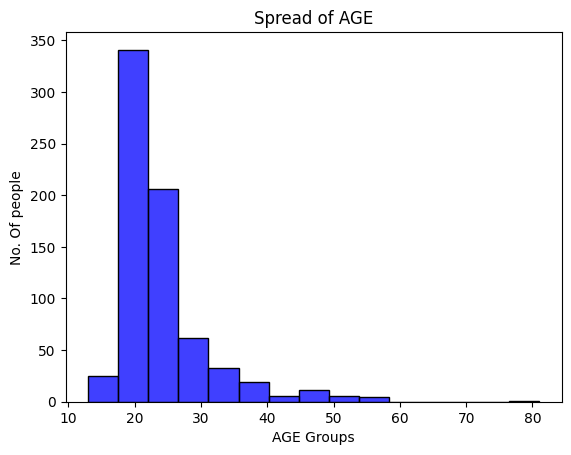

In [22]:
sns.histplot(df['Age'], bins = 15, color = 'blue')
plt.title('Spread of AGE')
plt.xlabel('AGE Groups')
plt.ylabel('No. Of people')

With the histogram of 'Age' we can see many people of differentage groups are there in the dataset with the majority of people being from 18-25 years of age

In [25]:
df['Gender'].unique()

array([1, 0, 2])

In [26]:
df['Gender'].value_counts()

,count
Gender,
1,373
0,335
2,7


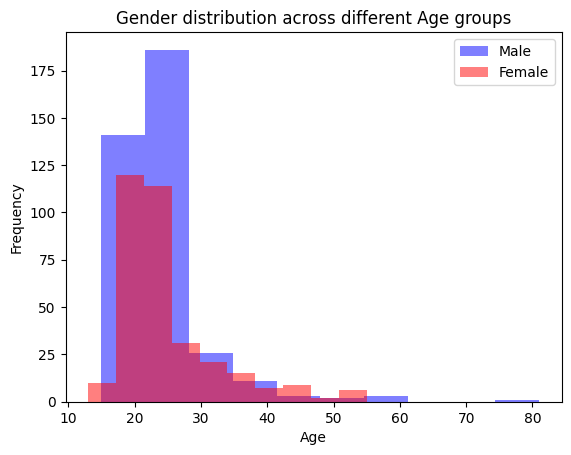

In [27]:
male = df[df['Gender'] == 1]['Age']
female = df[df['Gender'] == 0]['Age']

plt.hist(male, bins=10, alpha=0.5, label='Male', color='blue')
plt.hist(female, bins=10, alpha=0.5, label='Female', color='red')

plt.title('Gender distribution across different Age groups')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In this histplot we can see the Gender distribution across different age group

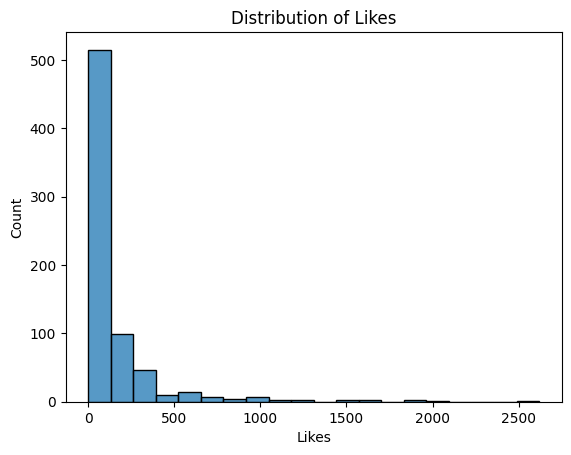

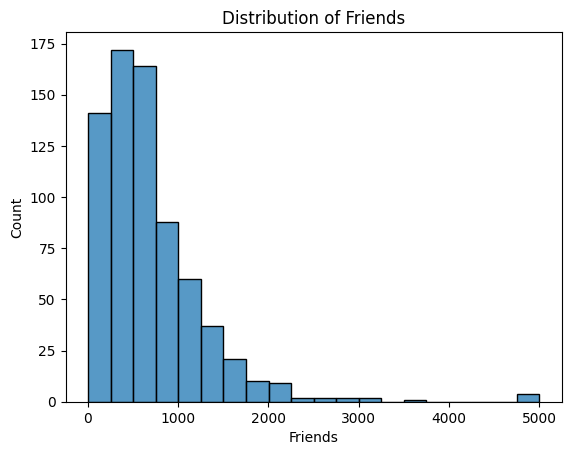

In [28]:
sns.histplot(df['Likes'], bins=20)
plt.title('Distribution of Likes')
plt.show()

sns.histplot(df['Friends'], bins=20)
plt.title('Distribution of Friends')
plt.show()

In this histplot we can see the "Likes" and "Friends" distribution showing us that majority of people have less than 150 likes on their posts and majority of people have less than 1000 friends. we can also see both the plots being right skewed indicating potential outliers on the high end side pulling the distribution towards the right.